In [29]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [30]:
class KozaiSystem:
    """
    Stores physical parameters of a hierarchical triple system
    in the test-particle, quadrupole approximation.
    """

    def __init__(self, A=1.0):
        """
        Parameters
        ----------
        A : float
            Dimensionless Kozai coupling constant
            (sets the secular timescale).
        """
        self.A = A


class KozaiIntegrator:
    """
    Integrates quadrupole-level Kozai–Lidov equations.
    """

    def __init__(self, system: KozaiSystem):
        self.system = system

    def equations(self, t, y):
        """
        Quadrupole Kozai–Lidov equations.

        Variables
        ---------
        y[0] = e      (eccentricity)
        y[1] = i      (inclination, radians)
        y[2] = omega  (argument of periapsis, radians)
        """
        e, inc, omega = y
        A = self.system.A

        # Avoid singularities
        if e >= 1.0:
            e = 0.999999

        de_dt = A * e * np.sin(inc)**2 * np.sin(2 * omega)

        di_dt = (
            -A * (e**2 / np.sqrt(1 - e**2))
            * np.sin(inc) * np.sin(2 * omega)
        )

        domega_dt = A * (
            2 + 3 * e**2 - 5 * np.sin(inc)**2 * np.sin(omega)**2
        )

        return [de_dt, di_dt, domega_dt]

    def integrate(self, y0, t_span, n_steps=5000):
        """
        Integrate the secular equations.

        Parameters
        ----------
        y0 : list
            Initial conditions [e0, i0, omega0]
        t_span : tuple
            (t_start, t_end)
        n_steps : int
            Number of time samples
        """
        t_eval = np.linspace(t_span[0], t_span[1], n_steps)

        sol = solve_ivp(
            self.equations,
            t_span,
            y0,
            t_eval=t_eval,
            method="RK45",
            rtol=1e-9,
            atol=1e-9
        )

        return sol
    
def kozai_constant(e, inc):
        """Kozai integral: should be conserved."""
        return np.sqrt(1 - e**2) * np.cos(inc)


def critical_inclination():
        """Critical Kozai angle in radians."""
        return np.arccos(np.sqrt(3 / 5))


In [31]:
# System and integrator
system = KozaiSystem(A=1.0)
integrator = KozaiIntegrator(system)

# Initial conditions
e0 = 0.1
i0 = np.radians(60)     # above critical angle
omega0 = np.pi / 4

# Semi-major axis (constant at quadrupole order)
a0 = 1.0

sol = integrator.integrate(
    y0=[e0, i0, omega0],
    t_span=(0, 80),
    n_steps=6000
)

t = sol.t
e, inc, omega = sol.y
a = np.full_like(t, a0)


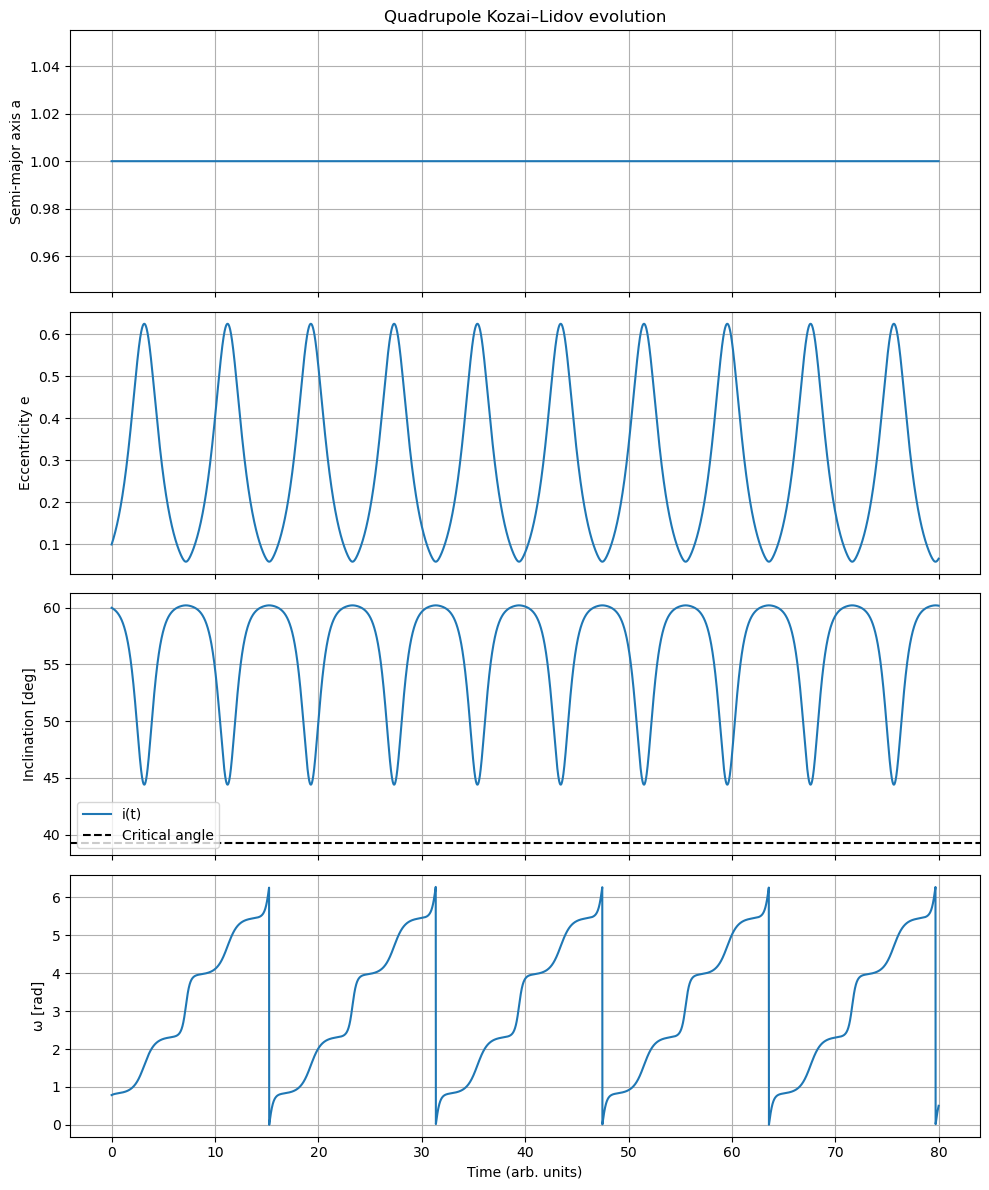

In [32]:
i_crit = critical_inclination()

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Semi-major axis
axes[0].plot(t, a)
axes[0].set_ylabel("Semi-major axis a")
axes[0].set_title("Quadrupole Kozai–Lidov evolution")
axes[0].grid()

# Eccentricity
axes[1].plot(t, e)
axes[1].set_ylabel("Eccentricity e")
axes[1].grid()

# Inclination
axes[2].plot(t, np.degrees(inc), label="i(t)")
axes[2].axhline(np.degrees(i_crit), color="k", linestyle="--",
                label="Critical angle")
axes[2].set_ylabel("Inclination [deg]")
axes[2].legend()
axes[2].grid()

# Argument of pericenter
axes[3].plot(t, np.mod(omega, 2*np.pi))
axes[3].set_ylabel("ω [rad]")
axes[3].set_xlabel("Time (arb. units)")
axes[3].grid()

plt.tight_layout()
plt.show()


In [33]:
omega_grid = np.linspace(0, 2*np.pi, 100)
inc_grid = np.linspace(
    np.radians(10),
    np.radians(80),
    80
)

e0 = 0.1


In [34]:
from tqdm import tqdm

e_max_map = np.zeros((len(inc_grid), len(omega_grid)))

for i, inc0 in enumerate(tqdm(inc_grid, desc="Inclination grid")):
    for j, omega0 in enumerate(omega_grid):

        sol = integrator.integrate(
            y0=[e0, inc0, omega0],
            t_span=(0, 20),
            n_steps=800
        )

        e_max_map[i, j] = sol.y[0].max()


Inclination grid: 100%|████████████████████████████████████████████████████████████████| 80/80 [24:14<00:00, 18.18s/it]


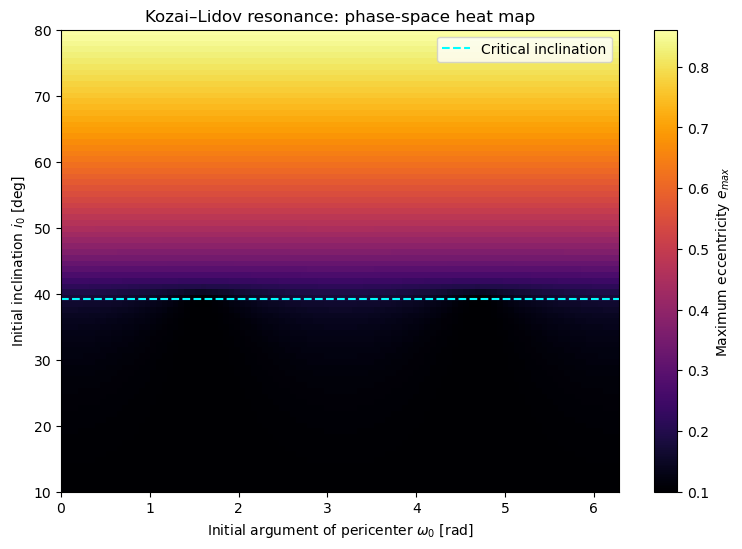

In [35]:
plt.figure(figsize=(9, 6))

extent = [
    0, 2*np.pi,
    np.degrees(inc_grid[0]),
    np.degrees(inc_grid[-1])
]

plt.imshow(
    e_max_map,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap="inferno"
)

plt.colorbar(label="Maximum eccentricity $e_{max}$")

plt.xlabel("Initial argument of pericenter $\\omega_0$ [rad]")
plt.ylabel("Initial inclination $i_0$ [deg]")
plt.title("Kozai–Lidov resonance: phase-space heat map")

# Critical angle
plt.axhline(
    np.degrees(critical_inclination()),
    color="cyan",
    linestyle="--",
    label="Critical inclination"
)

plt.legend()
plt.show()
